In [1]:
from pathlib import Path
from datetime import datetime, date
import xarray as xr

from wekeo_combined_chain import config

def get_combined_ds(date: date) -> xr.Dataset:
    """
    TODO: replace with S3 access instead
    """
    base = config.gridded_combined_downloaded_dir
    file = base / date.strftime("%Y_%m_%d/COMBINED_%Y-%m-%d_v1.0.nc")
    return xr.open_dataset(file)


day = date(2025, 8, 2)

ds = get_combined_ds(day)

print(ds)

<xarray.Dataset> Size: 942MB
Dimensions:                                 (latitude: 1636, longitude: 3272)
Coordinates:
  * latitude                                (latitude) float64 13kB -90.0 ......
  * longitude                               (longitude) float64 26kB -180.0 ....
Data variables: (12/44)
    s5p_pca__cloud_fraction_mean            (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_1_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_2_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_3_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__diag_CO_1_mean                 (latitude, longitude) float32 21MB ...
    s5p_pca__diag_CO_2_mean                 (latitude, longitude) float32 21MB ...
    ...                                      ...
    frp_slstr__day_FRP_SWIR_no_SAA_max      (latitude, longitude) float32 21MB ...
    frp_slstr__night_FRP_SWIR_no_SAA_mean   (latitude, longitude

In [2]:
areas = {
    "Global":          [ 90., -90.,  180., -180.],
    "North_America":   [ 90.,   9.,  -20., -169.],
    "South_America":   [  9., -60.,  -20.,  120.],
    "Europe":          [ 90.,  36.,   31.,  -20.],
    "Africa":          [ 36., -60.,   60.,  -20.],
    "Russia":          [ 90.,  36., -169.,   31.],
    "Asia":            [ 36., -10., -169.,   60.],
    "Australia":       [-10., -60., -120.,   60.],
    # "Central_Pacific": [  9., -10., -120., -169.],
    # "Antarctic":       [-60., -90.,  180., -180.],
}
    
from wekeo_combined_chain.utils import select_area

area_name = "Global"
area = areas[area_name]
    
ds_area = select_area(ds, area)

In [3]:
from wekeo_combined_chain import postprocess

ds_post, df_plumes = postprocess.compute(ds_area)

 ** S5P-PCA/FRP combined analysis **
 - Active FRP cells (filtered): 3120
 - Total number of plumes to process: 13
------------------------------------------
--> Plume #1
------------------------------------------
 Size         : 242 pixels
 Search buffer: initial=5px -> final=10px
                (iteratively expanded to search for FRP)

 FRP data     : [FOUND] 32px within plume, 98px in envelope

 SWIR source  : [--] not localized    (confidence: 0/2 - none)
 MWIR source  : [OK] localized        (confidence: 2/2 - high)
------------------------------------------
------------------------------------------
--> Plume #2
------------------------------------------
 Size         : 1997 pixels
 Search buffer: initial=8px -> final=13px
                (iteratively expanded to search for FRP)

 FRP data     : [FOUND] 47px within plume, 233px in envelope

 SWIR source  : [--] not localized    (confidence: 0/2 - none)
 MWIR source  : [OK] localized        (confidence: 2/2 - high)
--------------

In [4]:
from wekeo_combined_chain.postprocess import table as T

#print("Plumes:")
print("-" * 75)
#print(T.plume_table(df_plumes))
# MAJ 11/06/26
T.display_plume_tables(df_plumes)

print()
#print("Tiny plumes:")
print("-" * 75)
# MAJ 11/06/26
#print(T.tiny_plume_table(df_plumes))
T.display_tiny_plume_tables(df_plumes)

---------------------------------------------------------------------------
--- Plumes - General info ---


,Plume label,Size (pixels),Centroid lat (deg),Centroid lon (deg),FRP cells found
0,1,242,-7.206005,16.814191,130
1,2,1997,-5.071690,22.269125,280
2,3,116,40.990193,53.270803,0
3,4,160,51.030963,-80.089548,0
4,5,4434,54.935333,-97.083947,278
5,6,212,62.332179,-118.435611,26


--- Plumes - Fire scores (MWIR/day) ---


,Plume label,Fire score MWIR (day),FRP energy MWIR (MW),Mean CO score (no units)
0,1,3.021909,4095.328613,0.363304
1,2,3.485943,8628.605469,0.384636
2,3,NaN,NaN,0.396560
3,4,NaN,NaN,0.363863
4,5,5.197891,30410.234375,0.503546
5,6,2.559379,600.510620,0.399938


--- Plumes - Source localization (MWIR/day) ---


...

,Plume label,Size (pixels),Centroid lat (deg),Centroid lon (deg),FRP cells found
0,100,11,34.894078,-120.096688,5
1,101,1,54.880734,57.872861,0
2,102,1,61.486239,61.063570,0
3,103,1,63.577982,22.665037,0
4,104,1,68.311927,63.704156,0
5,105,1,68.642202,132.249389,2
6,106,1,77.119266,-86.589242,0


--- Tiny plumes (label >= 100) - Fire scores (MWIR/day) ---


,Plume label,Fire score MWIR (day),FRP energy MWIR (MW),Mean CO score (no units)
0,100,3.139135,687.852539,0.480355
1,101,NaN,NaN,0.954406
2,102,NaN,NaN,1.364947
3,103,NaN,NaN,0.638201
4,104,NaN,NaN,1.237733
5,105,1.967996,19.040615,0.656489
6,106,NaN,NaN,0.694199


--- Tiny plumes (label >= 100) - Source localization (MWIR/day) ---


,Plume label,Source localized,Source lat (deg),Source lon (deg),Source dist to centroid (km),Source confidence
0,100,1,35.06422,-120.091687,18.924389,high
1,101,0,NaN,NaN,NaN,none
2,102,0,NaN,NaN,NaN,none
3,103,0,NaN,NaN,NaN,none
4,104,0,NaN,NaN,NaN,none
5,105,0,NaN,NaN,NaN,none
6,106,0,NaN,NaN,NaN,none


In [5]:
from wekeo_combined_chain.postprocess import plot as P

date_str = day.strftime("%Y%m%d")
output_dir = Path("output") / day.strftime("%Y_%m_%d") / area_name
output_dir.mkdir(parents=True, exist_ok=True)


## Map 1 — Plumes × FRP overlay

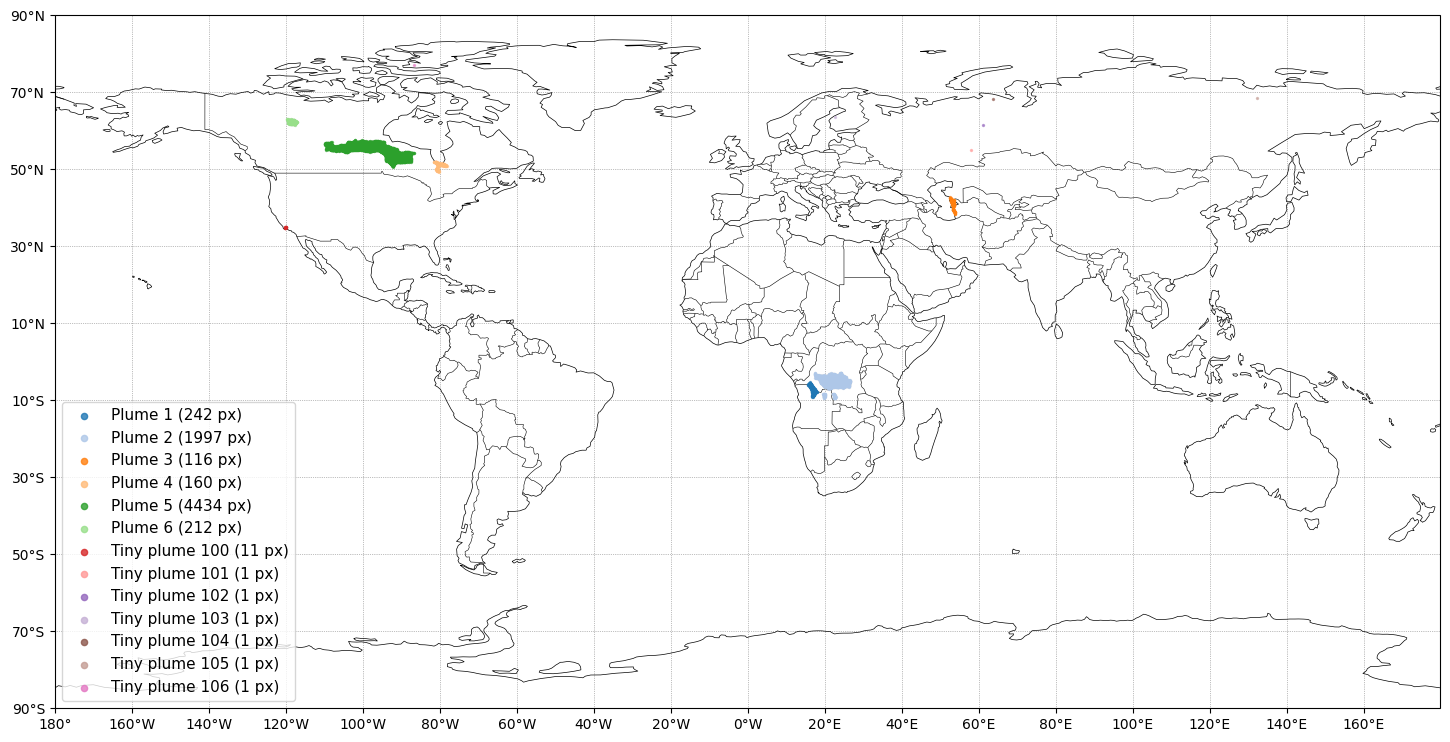

In [6]:
# Toggle save_to to write to disk, or leave None for inline display only
P.plot_plumes_frp(ds_area, ds_post, date_str, frp_channel="SWIR",
                  save_to=output_dir / f"plumes_frp_SWIR_{date_str}.png")


## Map 2 — Fire score per plume

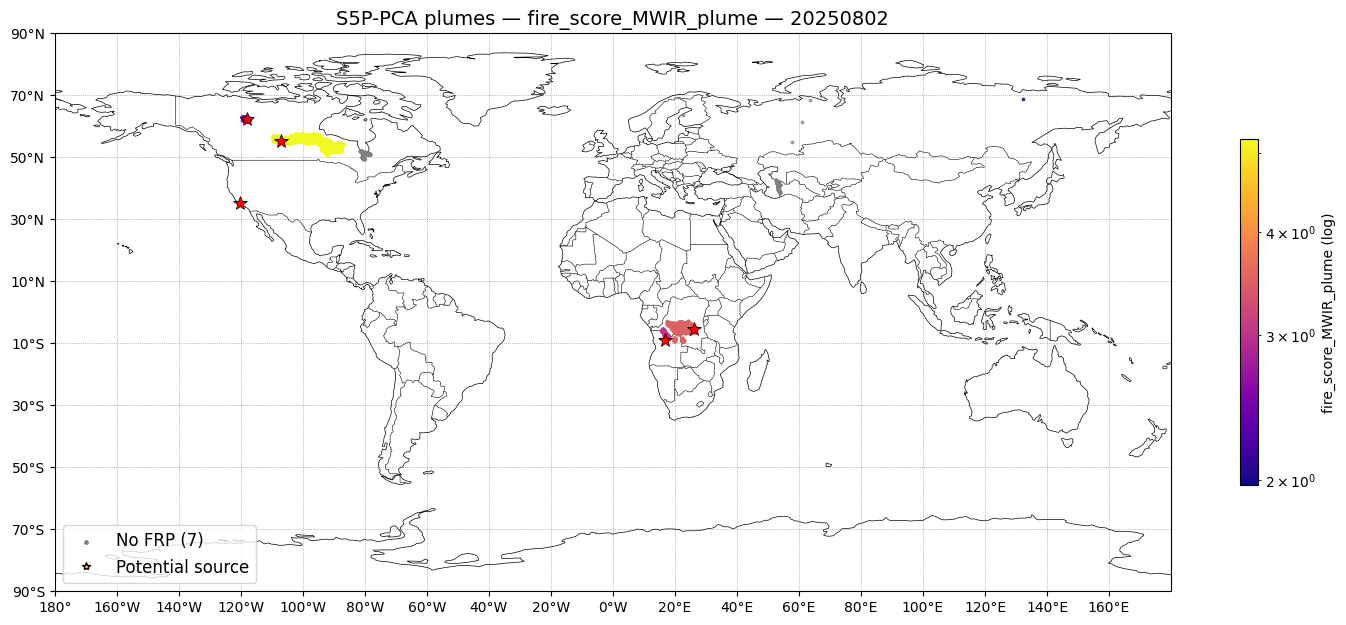

In [7]:
P.plot_fire_score_plume(ds_area, ds_post, df_plumes, date_str, band="MWIR",
                        save_to=output_dir / f"fire_score_plume_MWIR_{date_str}.png")


## Map 3 — Fire score per pixel

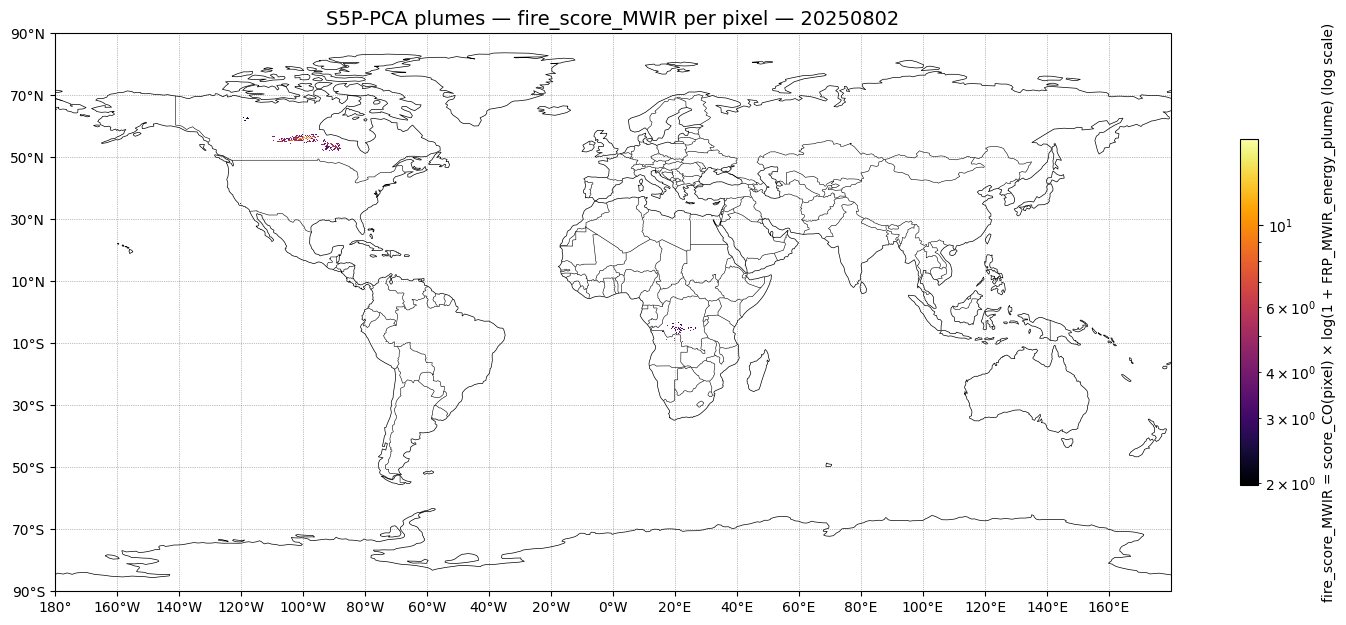

In [8]:
P.plot_fire_score_pixel(ds_area, ds_post, date_str, band="MWIR",
                        save_to=output_dir / f"fire_score_pixel_SWIR_{date_str}.png")
    

## Map 4 — Plume envelopes + source confidence

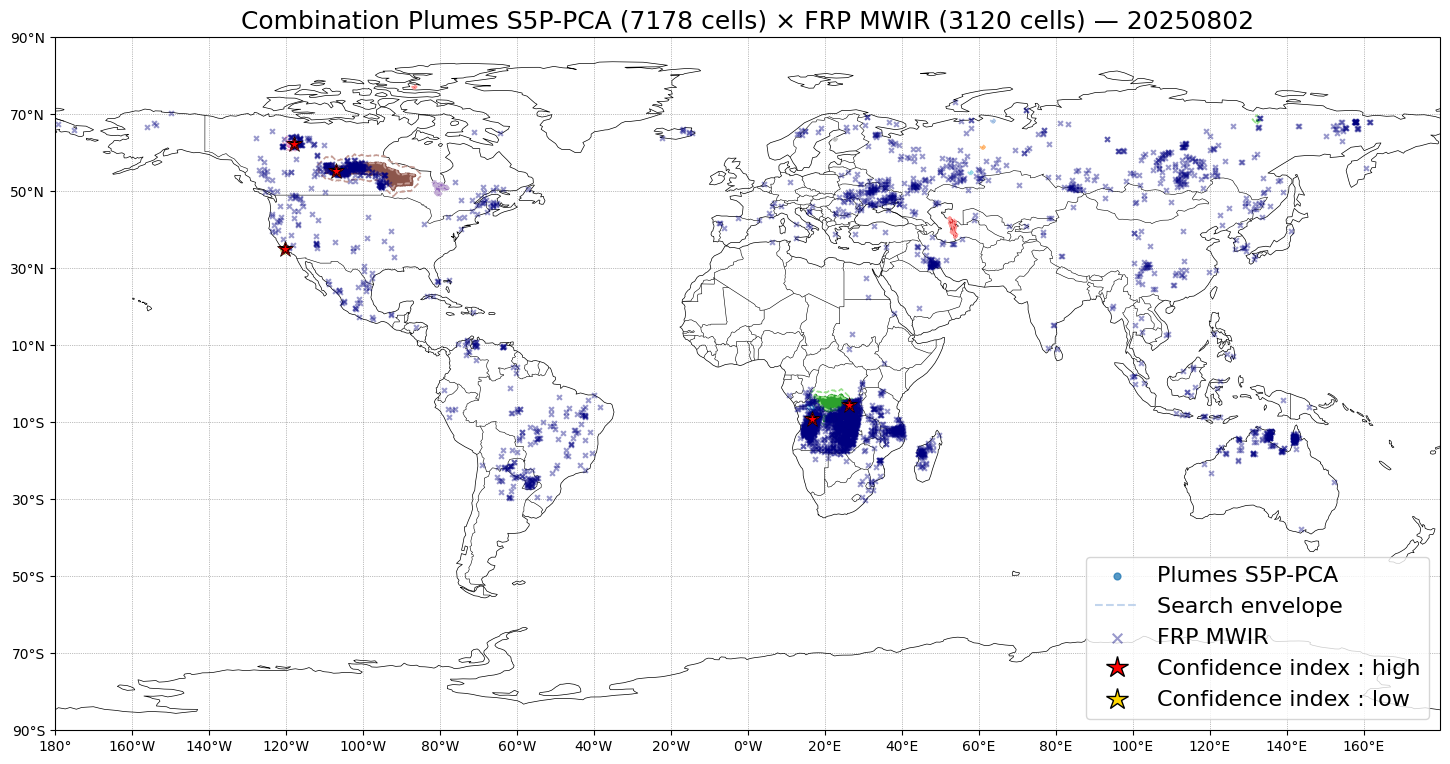

In [9]:
P.plot_plume_envelopes(ds_area, ds_post, df_plumes, date_str, frp_channel="MWIR",
                       save_to=output_dir / f"plume_envelopes_MWIR_{date_str}.png")


In [10]:
# end of demo